<a href="https://colab.research.google.com/github/manan36chauhan/data_science_project/blob/First-init/FinalAIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#https://www.kaggle.com/datasets/sahilislam007/college-student-placement-factors-dataset

The business problem is to predict whether a college student will secure a placement based on academic and extracurricular factors. This is important for a recruitment consultancy to identify enhance placement rates, and provide targeted support, benefiting the company by improving client satisfaction and revenue. Data is collected from university records. The problem is formulated as a binary classification task with **Placement** as the target

In [50]:
#First Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Load dataset

In [51]:
college_df = pd.read_csv('college_student_placement_dataset.csv')
print(college_df.head())

  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3                   1       

# Exploration of *data* EDA

In [52]:
print(college_df.describe())
print(college_df.info())
print("Number of Rows and colums or shape of Data",college_df.shape)

                 IQ  Prev_Sem_Result          CGPA  Academic_Performance  \
count  10000.000000     10000.000000  10000.000000          10000.000000   
mean      99.471800         7.535673      7.532379              5.546400   
std       15.053101         1.447519      1.470141              2.873477   
min       41.000000         5.000000      4.540000              1.000000   
25%       89.000000         6.290000      6.290000              3.000000   
50%       99.000000         7.560000      7.550000              6.000000   
75%      110.000000         8.790000      8.770000              8.000000   
max      158.000000        10.000000     10.460000             10.000000   

       Extra_Curricular_Score  Communication_Skills  Projects_Completed  
count            10000.000000          10000.000000        10000.000000  
mean                 4.970900              5.561800            2.513400  
std                  3.160103              2.900866            1.715959  
min                

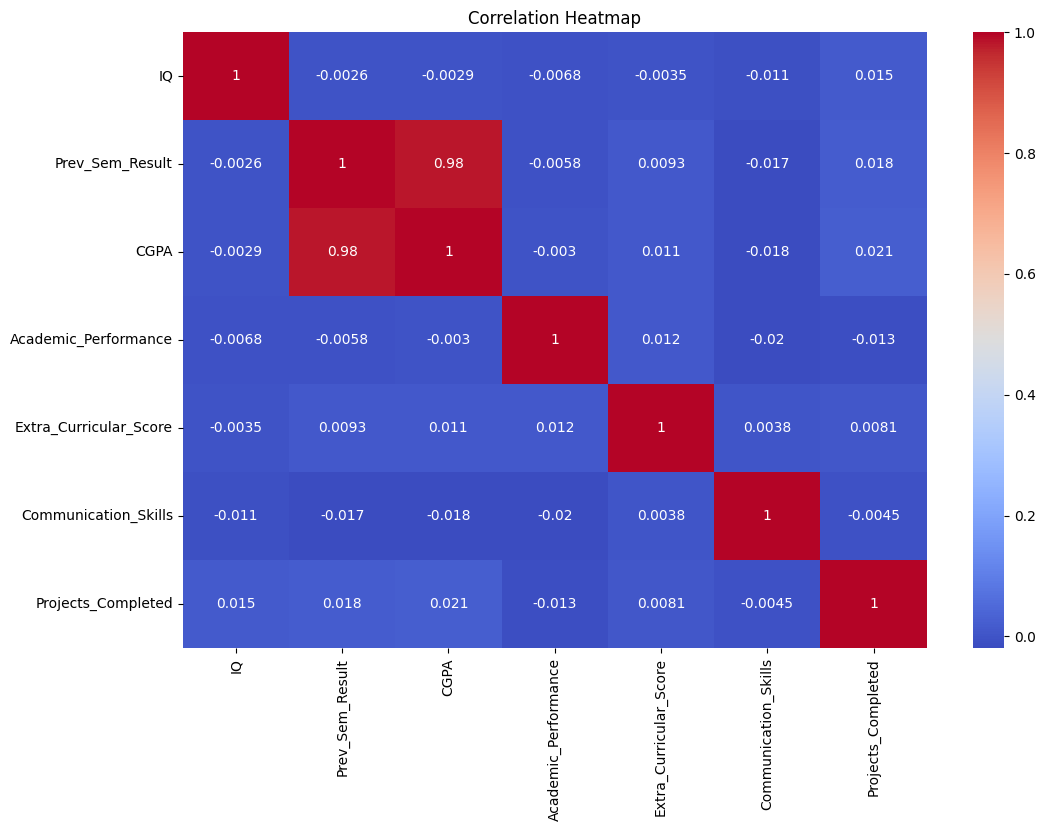

Placement
No     0.8341
Yes    0.1659
Name: proportion, dtype: float64


In [57]:
# Correlation heatmap (numeric features)
numeric_data = college_df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
print(college_df['Placement'].value_counts(normalize=True))

# Assuring if Dataset is clean or not

In [24]:
# Checking missing values
print(college_df.isna().sum())

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


In [25]:
if college_df.duplicated().sum() > 0:
    college_df.drop_duplicates(inplace=True)

In [26]:
if college_df.isna().sum().any():
    data = data.dropna()
else:
    print("Data is clean: No missing values.")

Data is clean: No missing values.


# Feture Engineering
Converting categorical data to numeric and drop irrelevant feature like College_ID

In [27]:
#Droppin irrelevant column or feature
college_df = college_df.drop('College_ID', axis=1)

#Converting cell "Yes" to 1 and "No" to =v0
college_df['Internship_Experience'] = college_df['Internship_Experience'].map({'Yes': 1, 'No': 0})
college_df['Placement'] = college_df['Placement'].map({'Yes': 1, 'No': 0})

#new feature added Performance_Score = CGPA + Prev_Sem_Result
college_df['Performance_Score'] = college_df['CGPA'] + college_df['Prev_Sem_Result']

In [30]:
print("adding new feature", college_df.head())
print("After Feature Engineering dataset shape :",college_df.shape)
# We have removed one unnecessary column college Id and added new colum performance score

adding new feature     IQ  Prev_Sem_Result  CGPA  Academic_Performance  Internship_Experience  \
0  107             6.61  6.28                     8                      0   
1   97             5.52  5.37                     8                      0   
2  109             5.36  5.83                     9                      0   
3  122             5.47  5.75                     6                      1   
4   96             7.91  7.69                     7                      0   

   Extra_Curricular_Score  Communication_Skills  Projects_Completed  \
0                       8                     8                   4   
1                       7                     8                   0   
2                       3                     1                   1   
3                       1                     6                   1   
4                       8                    10                   2   

   Placement  Performance_Score  
0          0              12.89  
1          0     

## Checking the Distribution of Placement

In [31]:
distribution = college_df['Placement'].value_counts()
print(distribution)

Placement
0    8341
1    1659
Name: count, dtype: int64


# Train and test spliting in to ratio train 80% and test 20%

In [32]:
X = college_df.drop('Placement', axis=1)
y = college_df['Placement']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

**preprocessing**

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train **model**

In [41]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = classification_report(y_test, y_pred, output_dict=True)
    print(f"{name} Report:\n{classification_report(y_test, y_pred)}")

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1668
           1       0.78      0.59      0.67       332

    accuracy                           0.90      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000

Decision Tree Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1668
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Random Forest Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1668
           1       1.00      0.99      1.00       332

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
we

Best Model: Decision Tree


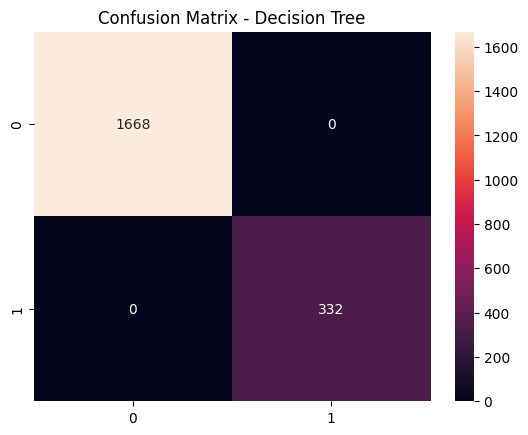

In [42]:
# Example for best model
best_name = max(results, key=lambda k: results[k]['weighted avg']['f1-score'])
print(f"Best Model: {best_name}")

# Confusion matrix for best
best_model = models[best_name]
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

 Tune Hyperparameters
Tune the best model using GridSearchCV.

In [43]:
# Assuming RandomForest is best
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='f1_weighted')
grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_
print(f"Best Params: {grid.best_params_}")

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


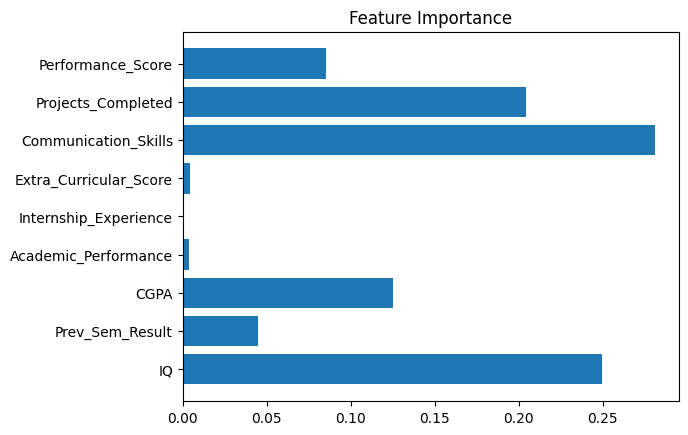

In [44]:

importances = best_model.feature_importances_
features = X.columns
plt.barh(features, importances)
plt.title('Feature Importance')
plt.show()



# Visualization

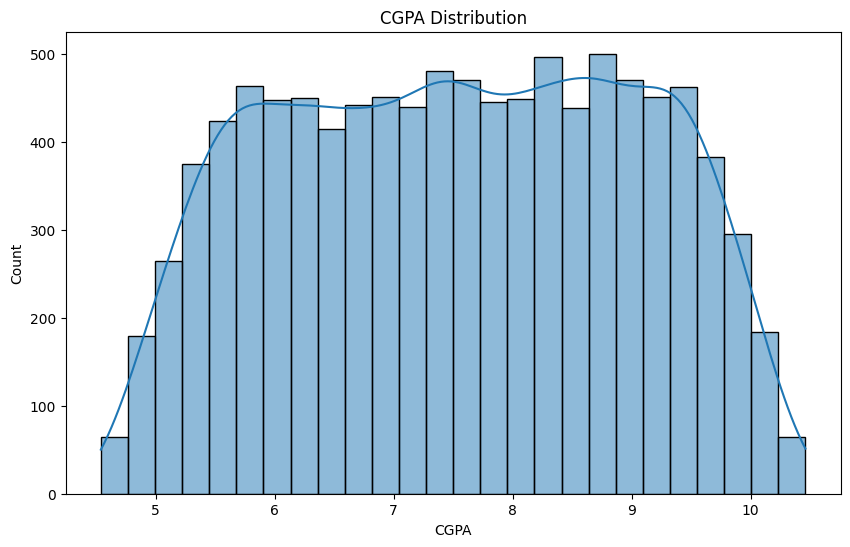

In [46]:
# Visualizations
plt.figure(figsize=(10,6))
sns.histplot(college_df['CGPA'], kde=True)
plt.title('CGPA Distribution')
plt.show()